## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
import plotly.io as pio

if "vscode" in pio.renderers:
    pio.renderers.default = "vscode"
else:
    pio.renderers.default = "png"

In [3]:
pd.set_option("display.max_columns",None)

## 2. Load Dataset

In [4]:
df = pd.read_csv("Life Expectancy Data.csv")

## 3. Data Understanding

In [5]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [6]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [7]:
df.columns = [col.strip() for col in df.columns]
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [8]:
df.isna().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [10]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


## 4. Data Cleaning

In [11]:
df.dropna(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(1649, 22)

## 5. Exploratory Data Analysis

In [14]:
#correlation analysis
plt.figure(figsize=(8,6))
corr=df.select_dtypes(include=np.number).corr()

<Figure size 800x600 with 0 Axes>

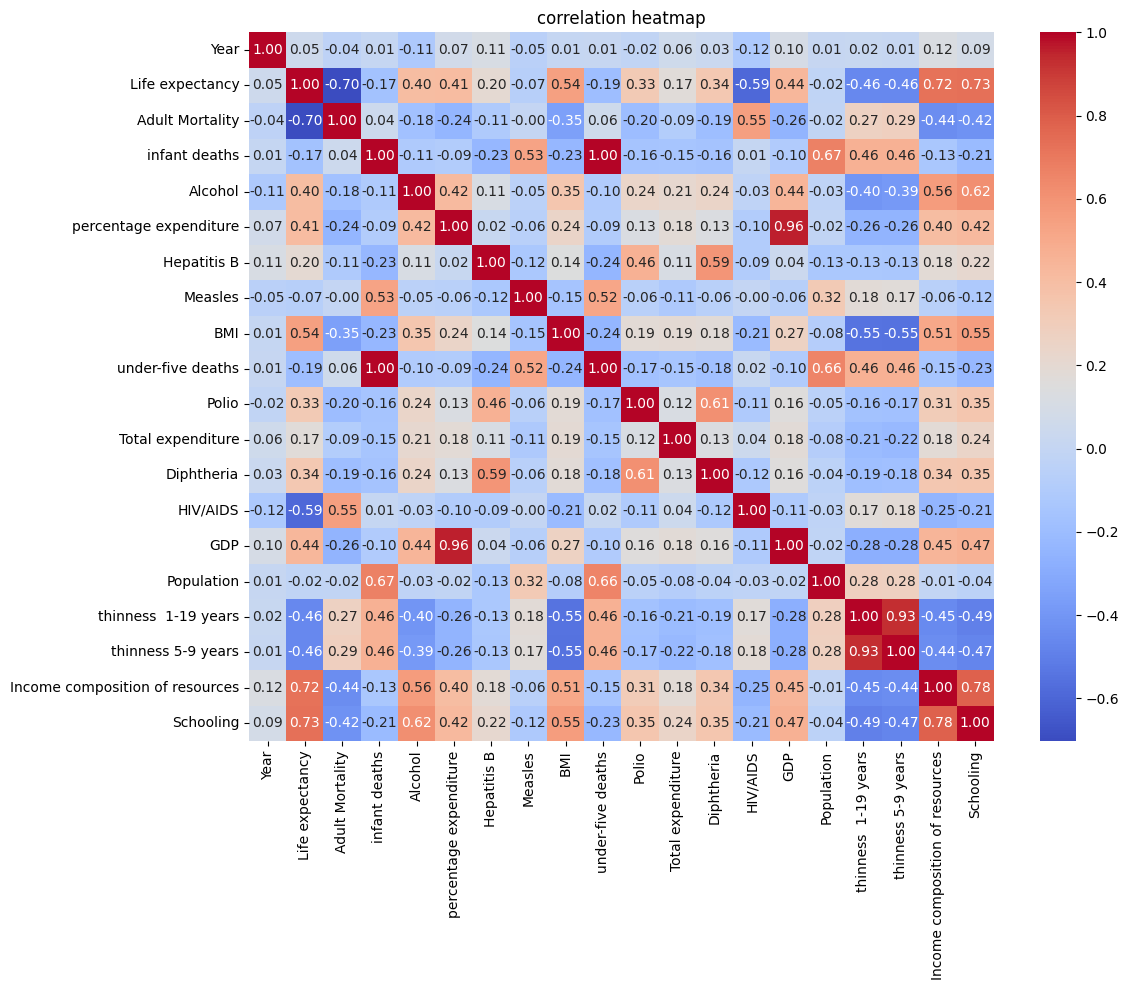

In [15]:
#correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("correlation heatmap")
plt.tight_layout()
plt.show()

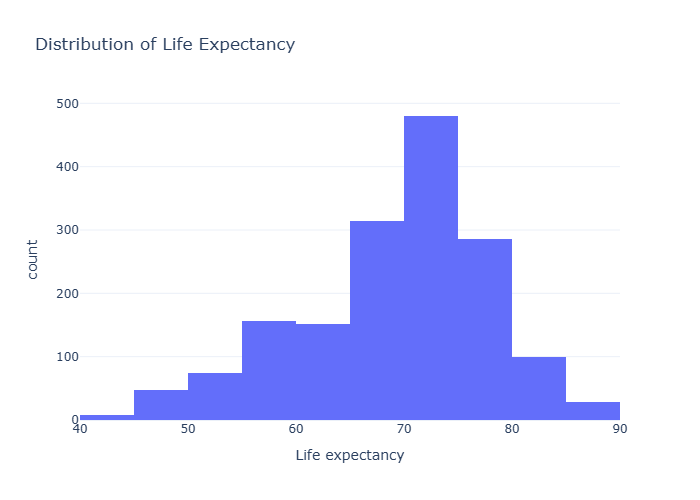

In [16]:
# Distribution of Life Expectancy
px.histogram(df, x="Life expectancy", nbins=20, title="Distribution of Life Expectancy",template="plotly_white").show("png")

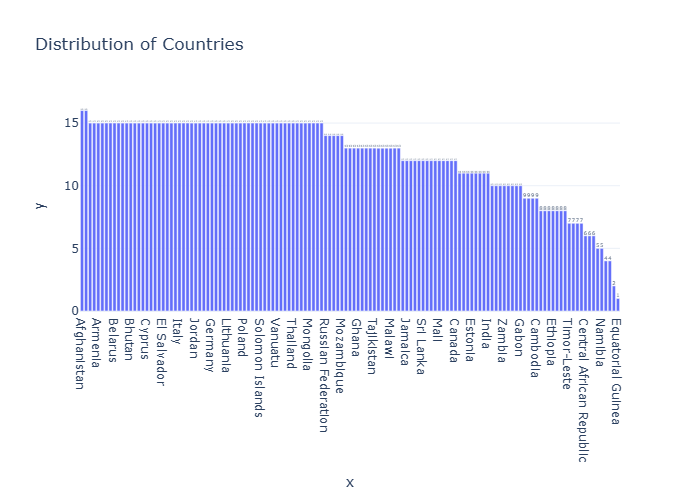

In [17]:
# Country distribution
px.bar(x=df["Country"].value_counts().index, y=df["Country"].value_counts().values,
       title="Distribution of Countries", text=df["Country"].value_counts().values,template="plotly_white").show("png")

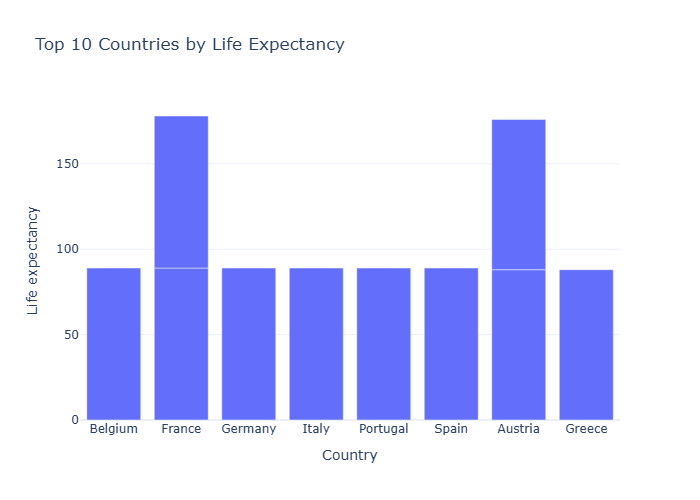

In [18]:
# Top 10 countries by Life Expectancy
px.bar(df.nlargest(10, 'Life expectancy'), x="Country", y="Life expectancy",
       title="Top 10 Countries by Life Expectancy",template="plotly_white").show("png")

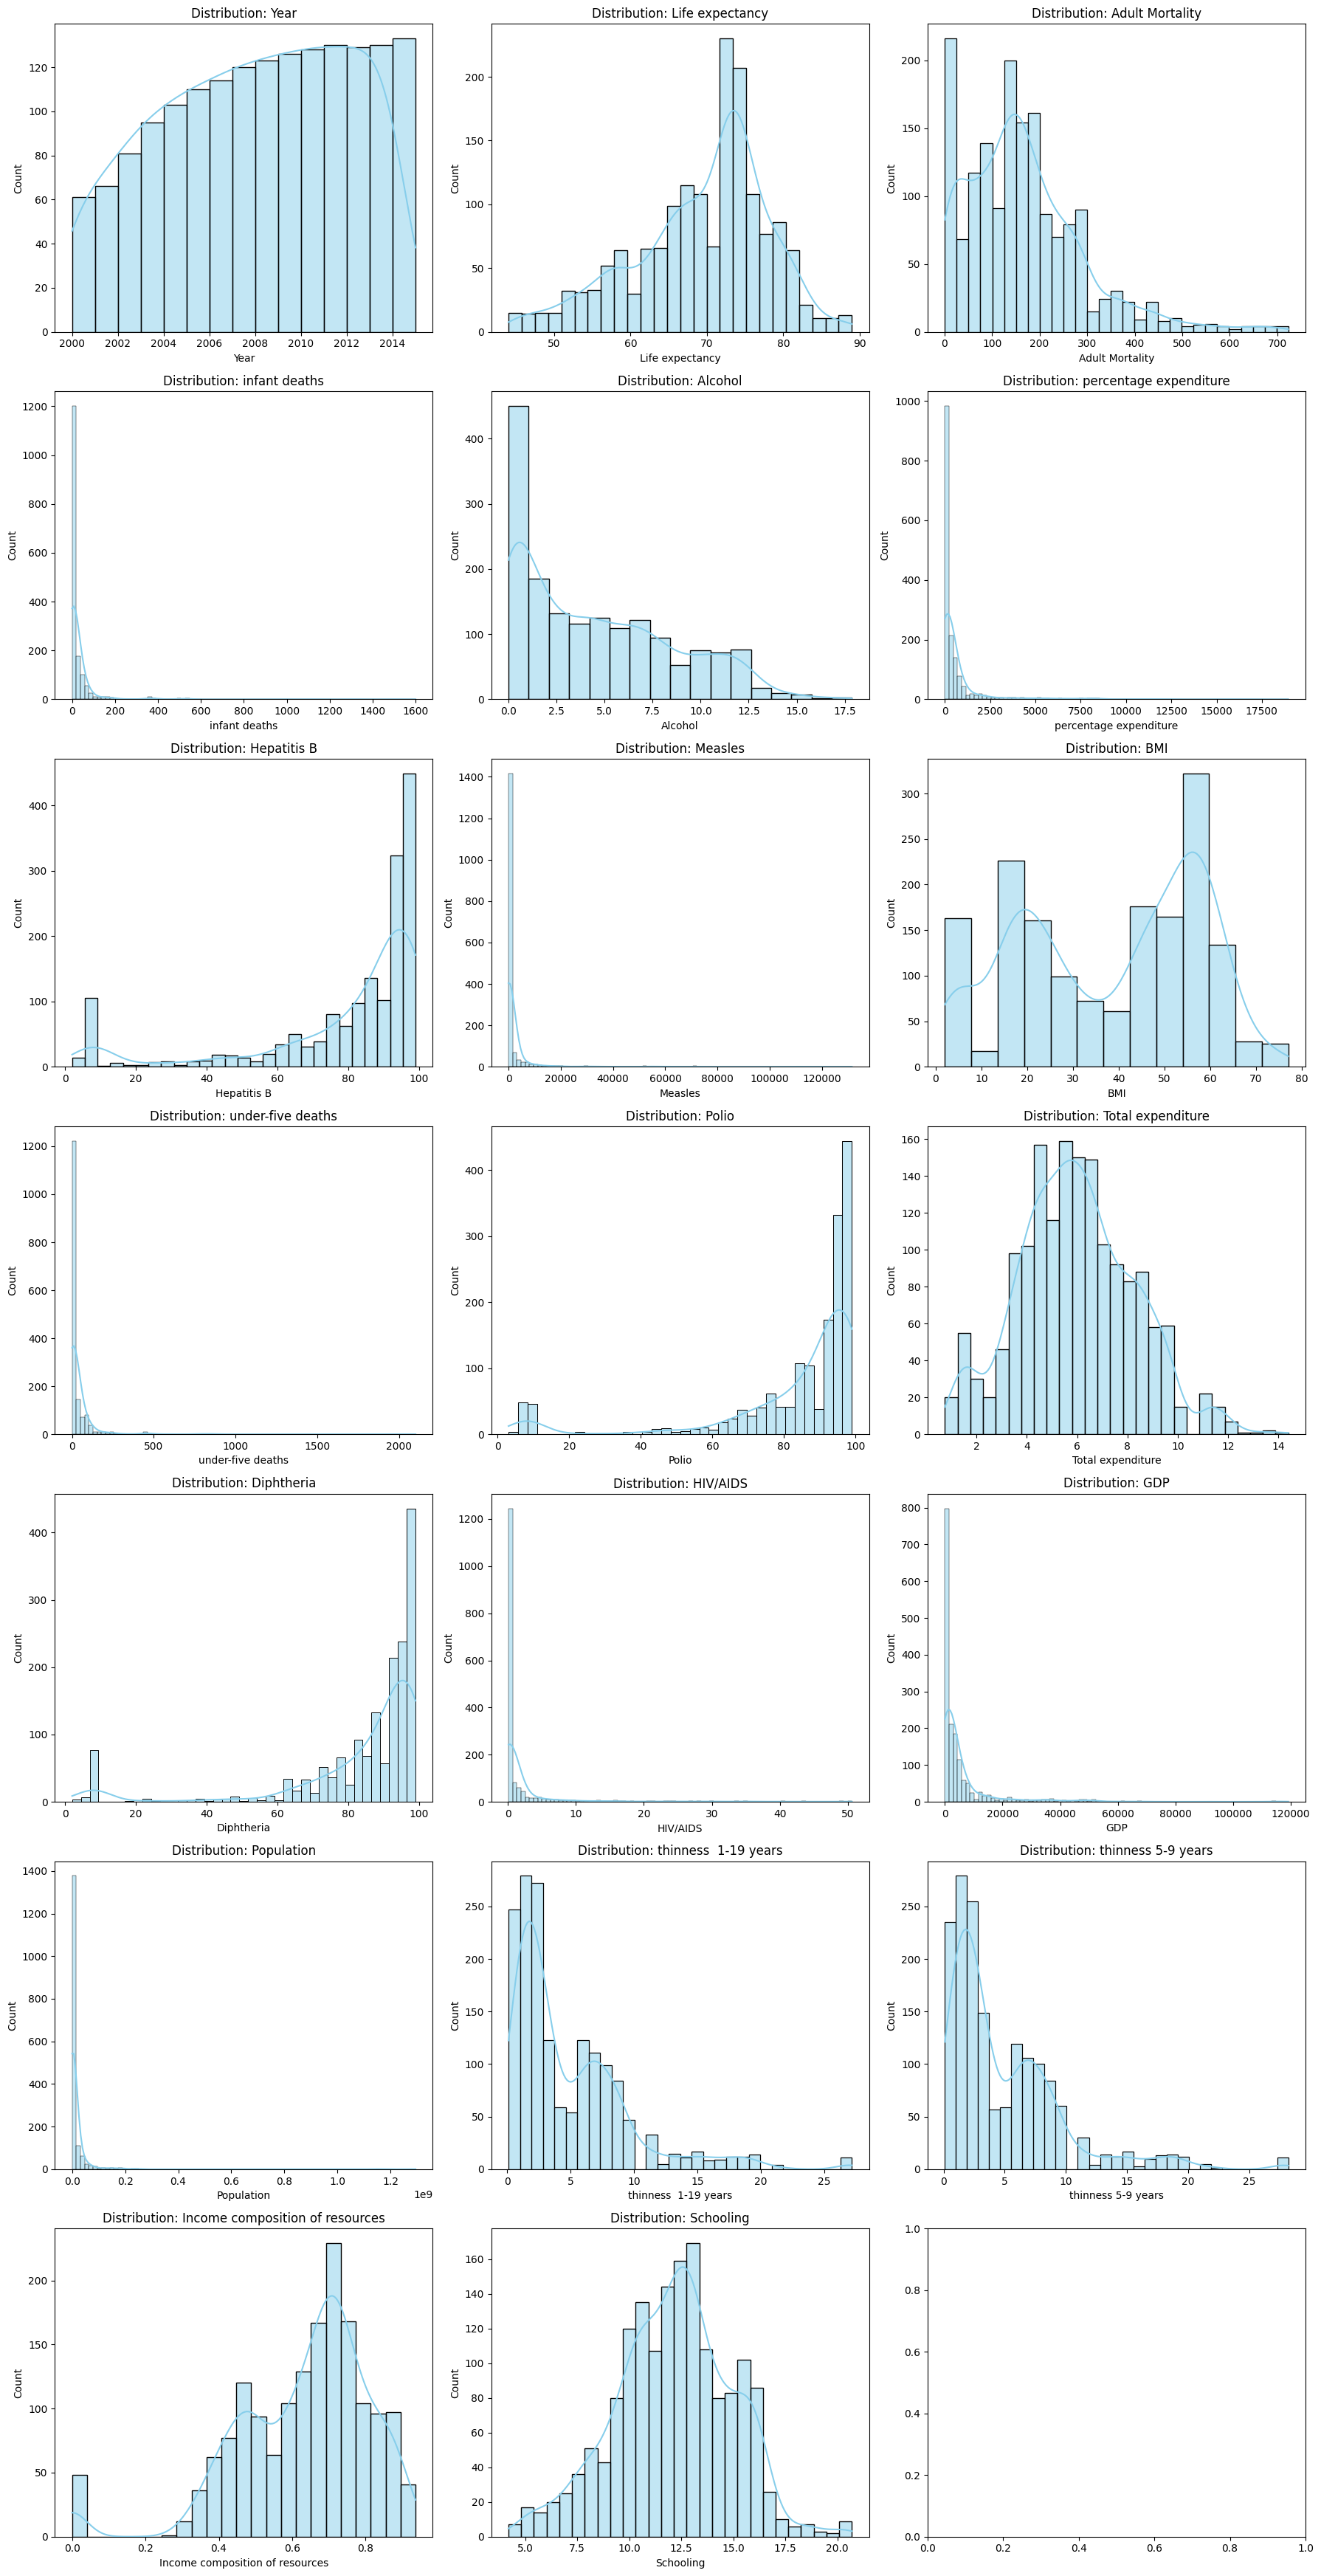

In [19]:
# Histograms with KDE
num_cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(nrows=int(np.ceil(len(num_cols)/3)), ncols=3, figsize=(18, 5*int(np.ceil(len(num_cols)/3))))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

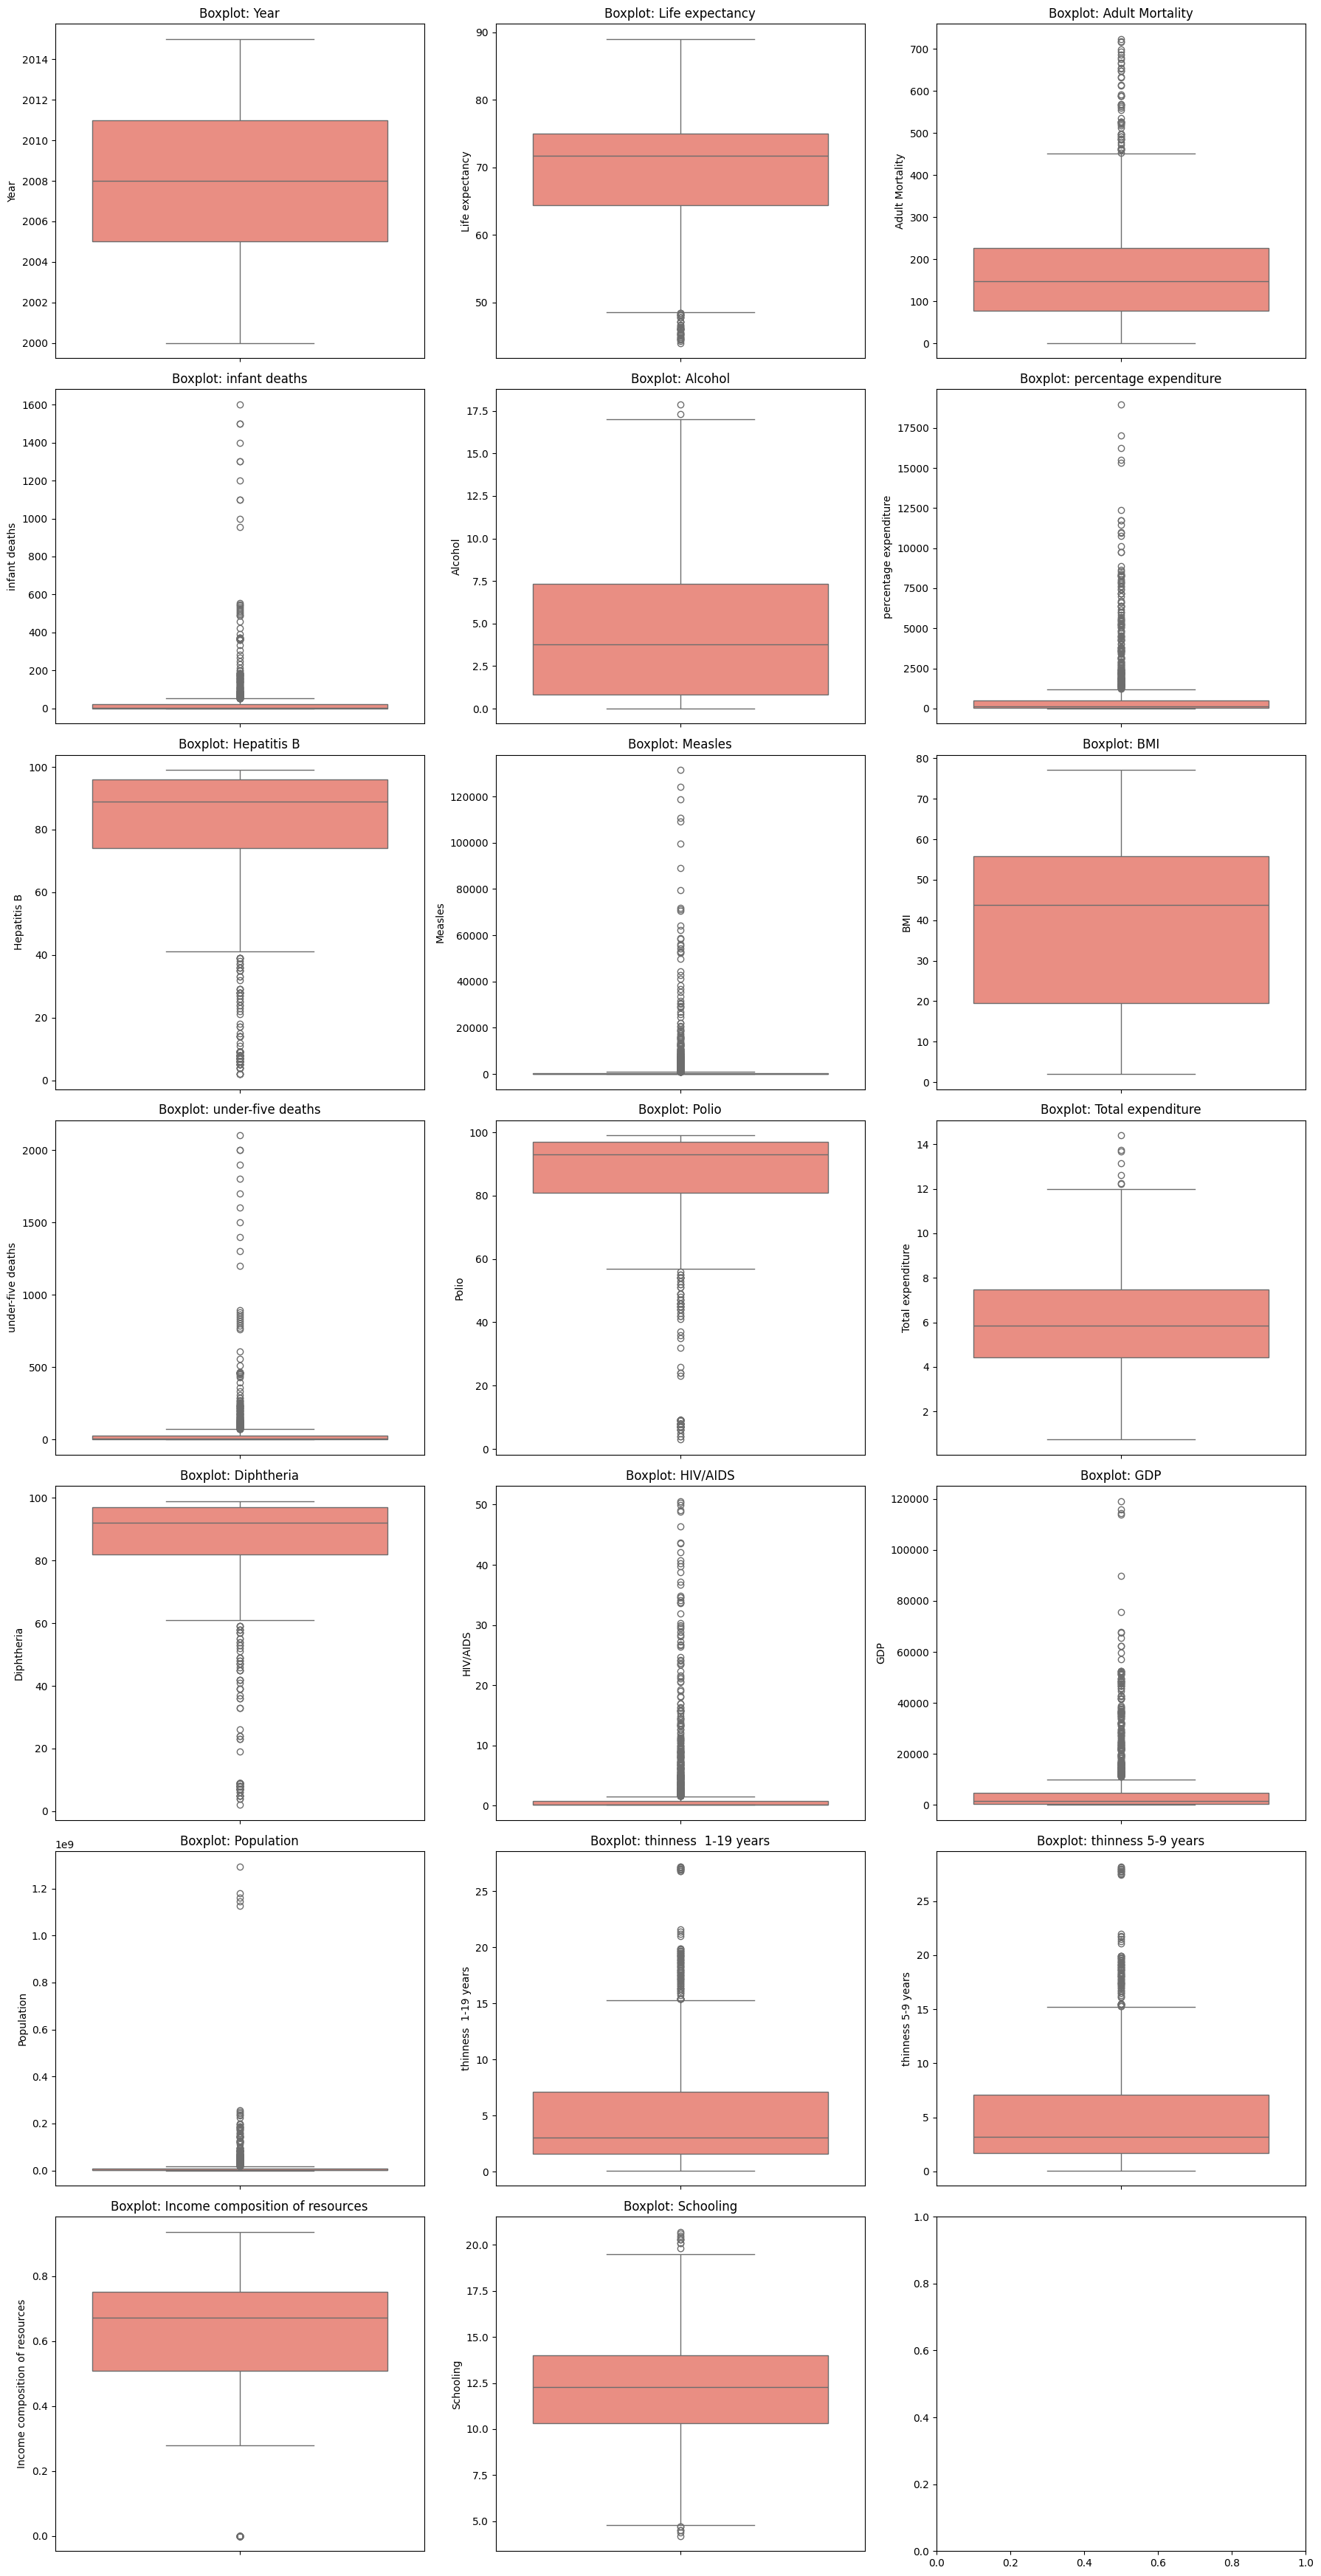

In [20]:
# Boxplots for outlier detections
fig, axes = plt.subplots(nrows=int(np.ceil(len(num_cols)/3)), ncols=3, figsize=(18, 5*int(np.ceil(len(num_cols)/3))))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

In [21]:
# Outlier treatment with IQR method for select columns
outlier_cols = ["Adult Mortality", "infant deaths", "percentage expenditure", "Hepatitis B", "Measles", "under-five deaths",
                "Polio", "Total expenditure", "Diphtheria", "HIV/AIDS", "GDP", "Population", "thinness  1-19 years",
                "thinness 5-9 years", "Income composition of resources", "Schooling"]
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    ll = q1 - 1.5 * iqr
    ul = q3 + 1.5 * iqr
    df[col]=np.clip(df[col],ll,ul)

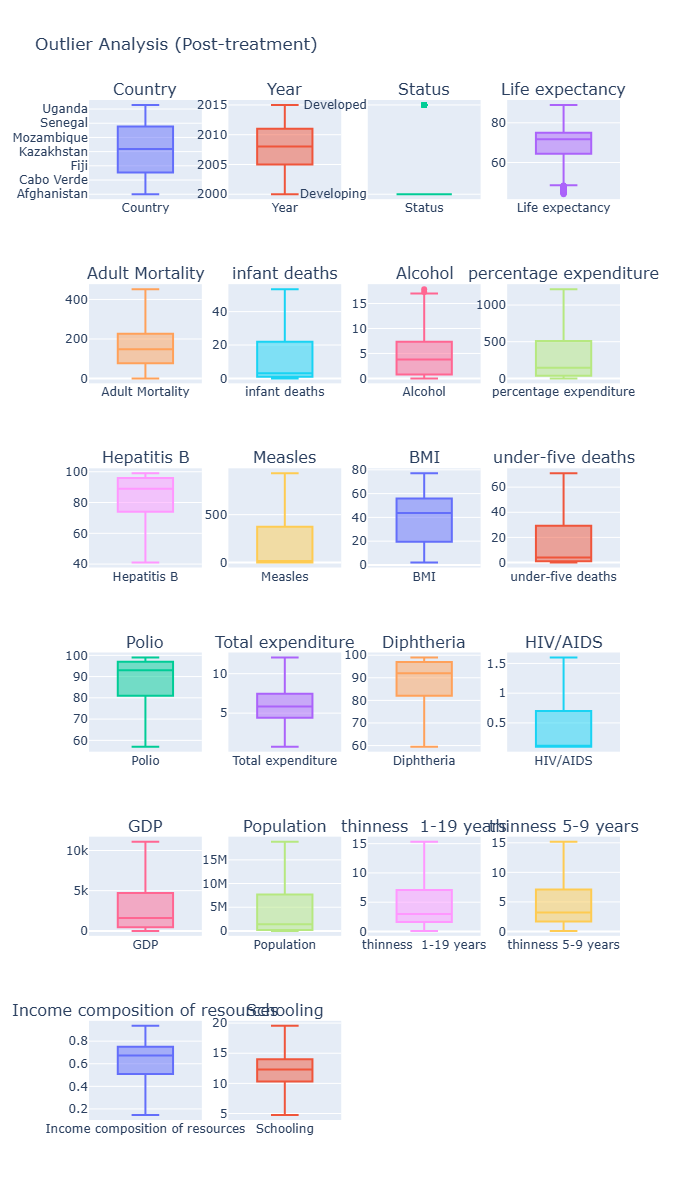

In [22]:
# Boxplots after treatment
fig = make_subplots(rows=6, cols=4, subplot_titles=tuple(df.columns))
for i, col in enumerate(df.columns):
    row, col_idx = i // 4 + 1, i % 4 + 1
    fig.add_trace(go.Box(y=df[col], name=col, boxpoints="outliers"), row=row, col=col_idx)
fig.update_layout(height=1200, showlegend=False, title_text="Outlier Analysis (Post-treatment)")
fig.show("png")

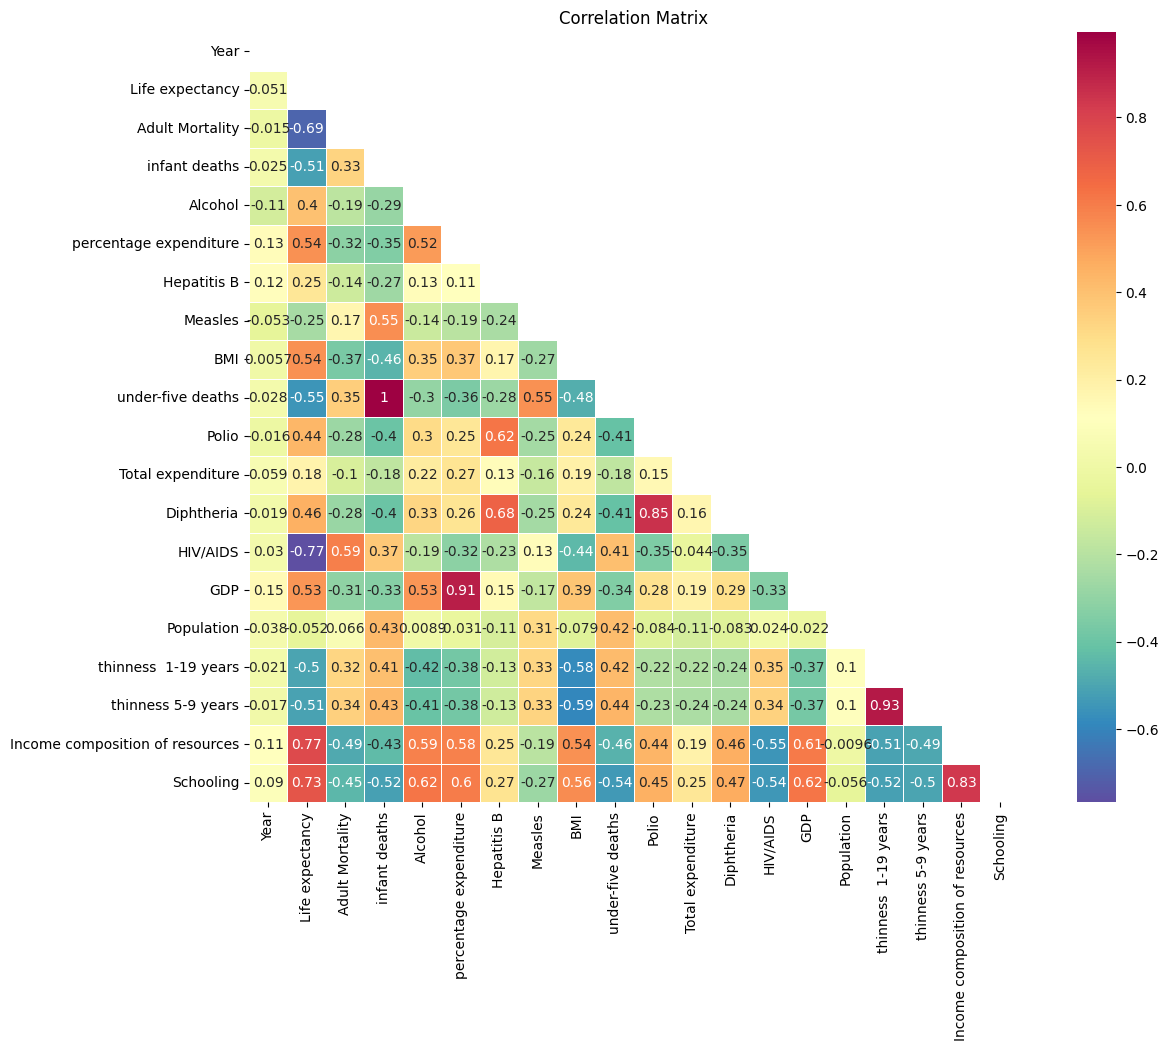

In [23]:
# Correlation heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), mask=np.triu(np.ones_like(df.select_dtypes(include=np.number).corr(), dtype=bool)),
            cmap="Spectral_r", annot=True, square=True, linewidth=0.5)
plt.title("Correlation Matrix")
plt.show()

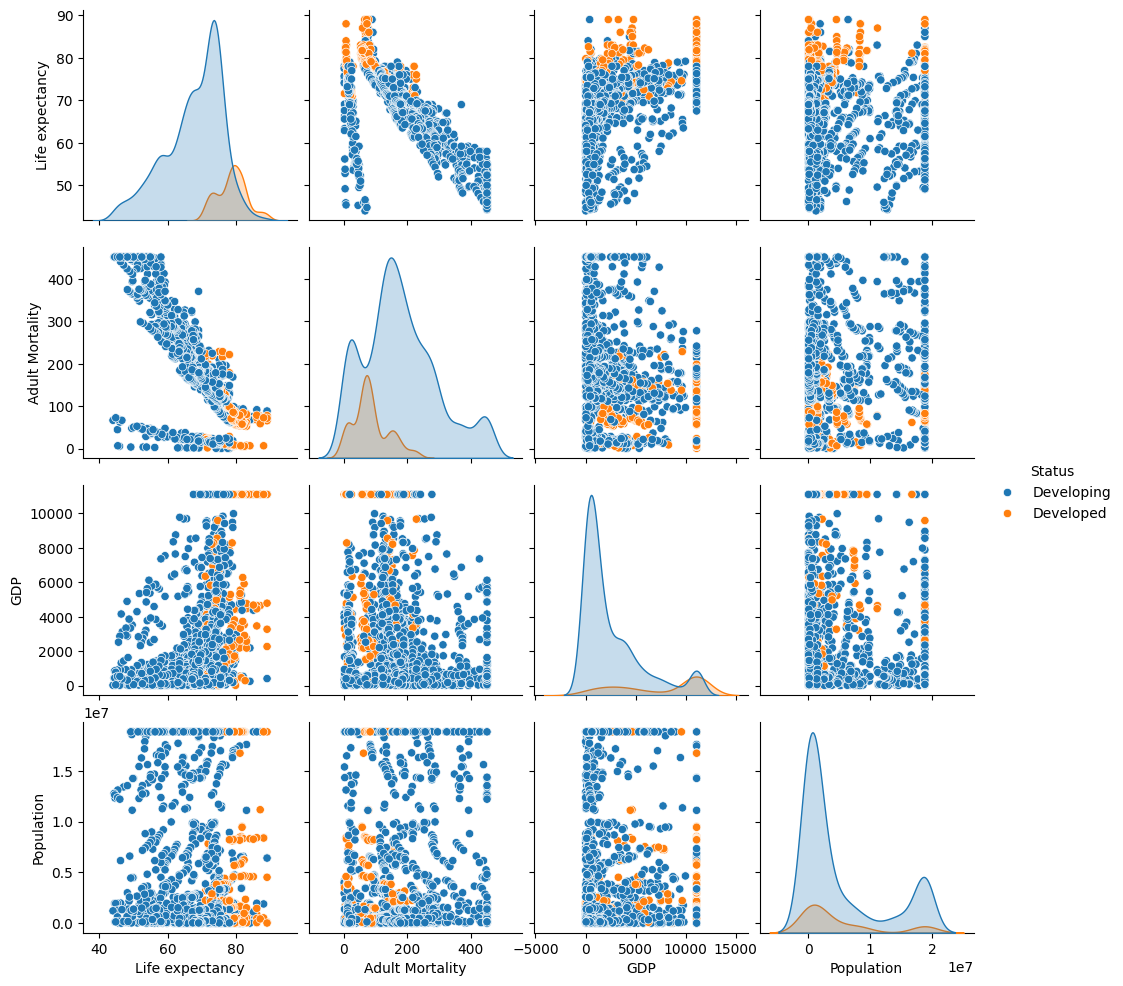

In [24]:
# Pairplot
sns.pairplot(df[["Life expectancy","Adult Mortality","GDP","Population","Status"]], hue="Status")
plt.show()

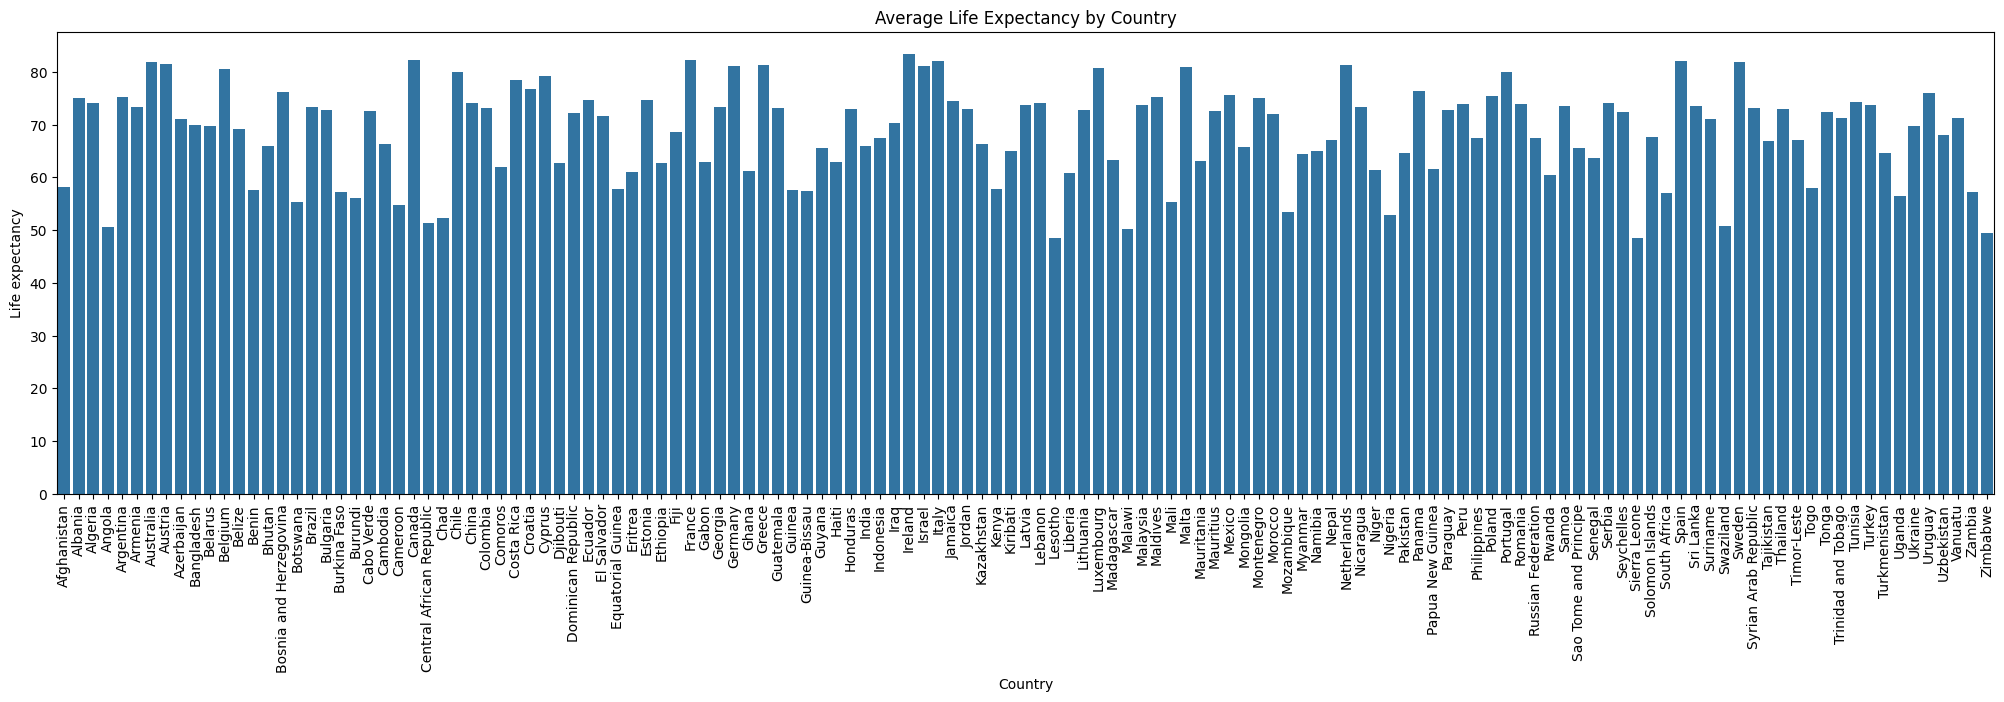

In [25]:
# Average Life Expectancy by Country
plt.figure(figsize=(25, 6))
sns.barplot(x="Country", y="Life expectancy", data=df.groupby("Country")["Life expectancy"].mean().reset_index())
plt.title("Average Life Expectancy by Country")
plt.xticks(rotation=90)
plt.show()

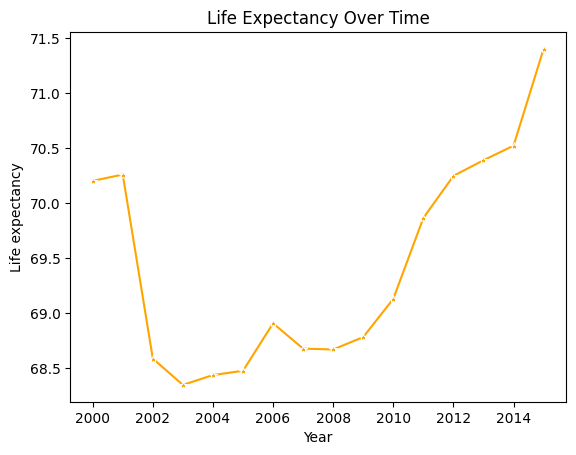

In [26]:
# Life Expectancy over Years
sns.lineplot(x="Year", y="Life expectancy", data=df.groupby("Year")["Life expectancy"].mean().reset_index(),
             marker="*", color="orange")
plt.title("Life Expectancy Over Time")
plt.show()

In [27]:
# Interactive scatter plot
px.scatter(df, x="Population", y="Life expectancy", hover_name="Country", size="GDP",
           size_max=30, color="Status", animation_frame="Year", template='plotly_dark',
           title="Population vs Life Expectancy").show()

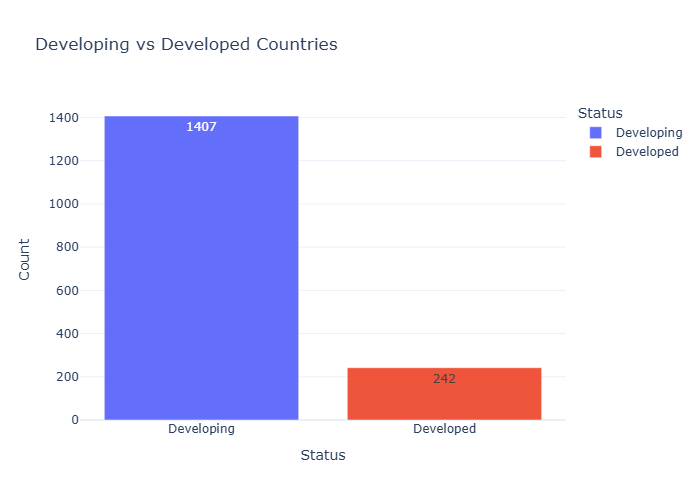

In [28]:
# Status distribution
status_counts = df['Status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']
px.bar(data_frame=status_counts, x='Status', y='Count',
       color="Status",text='Count', title="Developing vs Developed Countries",template="plotly_white").show("png")

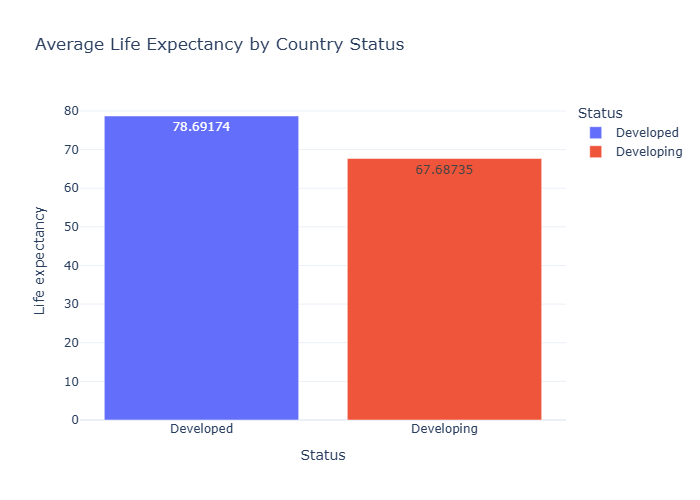

In [29]:
# Life Expectancy by Status
px.bar(df.groupby("Status")["Life expectancy"].mean().reset_index(), x="Status", y="Life expectancy",
       color="Status", title="Average Life Expectancy by Country Status", text_auto=True,template="plotly_white").show("png")

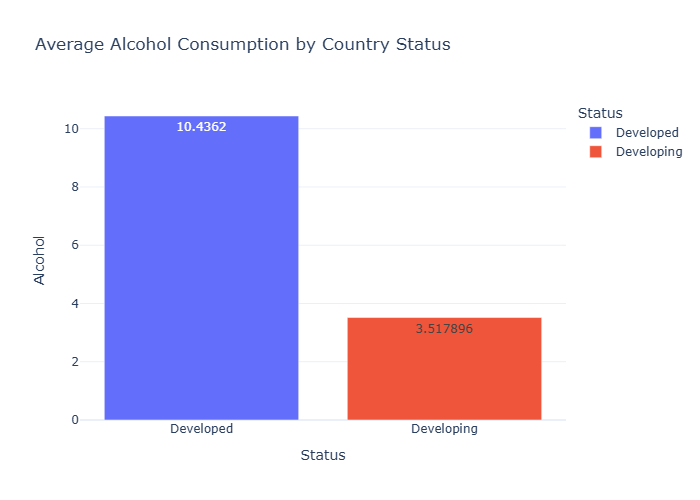

In [30]:
# Alcohol by Status
px.bar(df.groupby("Status")["Alcohol"].mean().reset_index(), x="Status", y="Alcohol",
       color="Status",title="Average Alcohol Consumption by Country Status", text_auto=True,template="plotly_white").show("png")

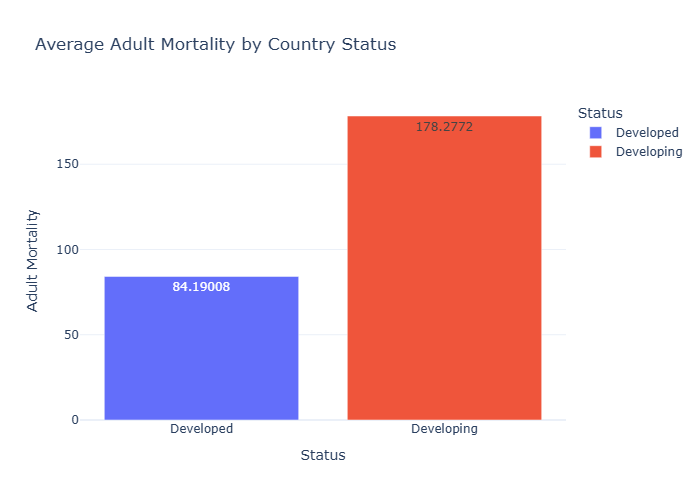

In [31]:
# Adult Mortality by Status
px.bar(df.groupby("Status")["Adult Mortality"].mean().reset_index(), x="Status", y="Adult Mortality",
       color="Status",title="Average Adult Mortality by Country Status", text_auto=True,template="plotly_white").show("png")

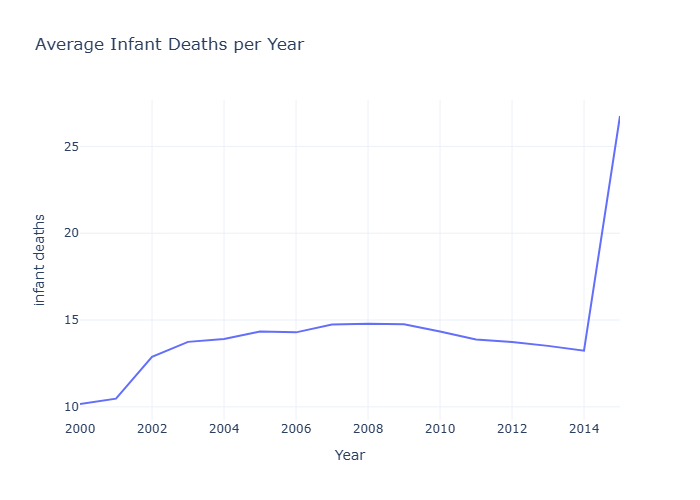

In [32]:
# Infant deaths over years
px.line(df.groupby("Year")["infant deaths"].mean().reset_index(), x="Year", y="infant deaths",
        title="Average Infant Deaths per Year",template="plotly_white").show("png")

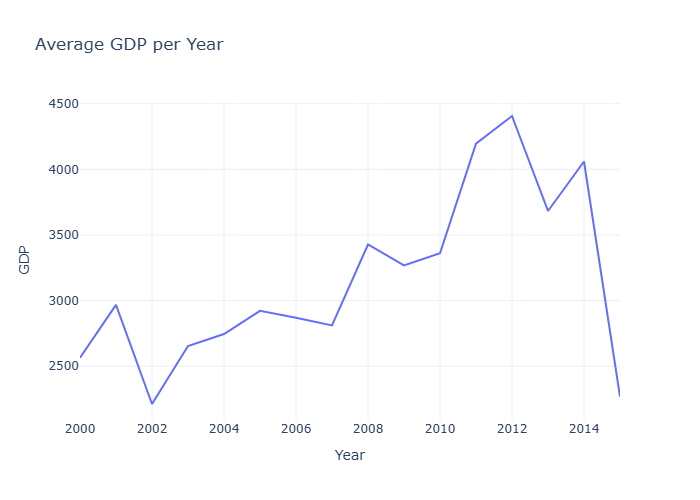

In [33]:
#GDP over years
px.line(df.groupby("Year")["GDP"].mean().reset_index(), x="Year", y="GDP",
        title="Average GDP per Year",template="plotly_white").show("png")

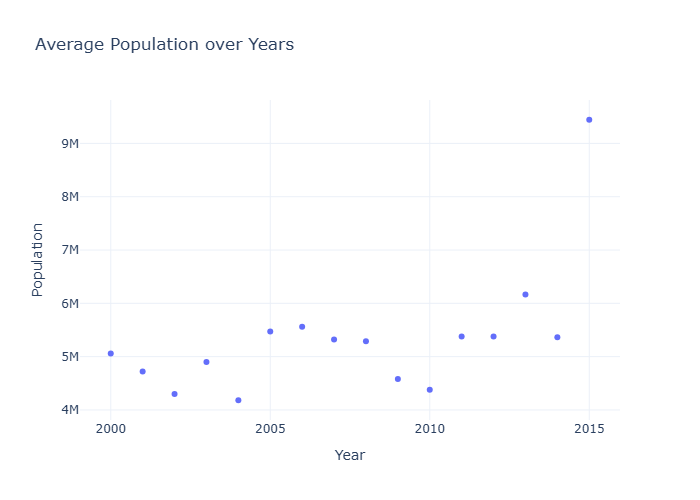

In [34]:
# Population over years
px.scatter(df.groupby("Year")["Population"].mean().reset_index(), x="Year", y="Population",
           title="Average Population over Years",template="plotly_white").show("png")

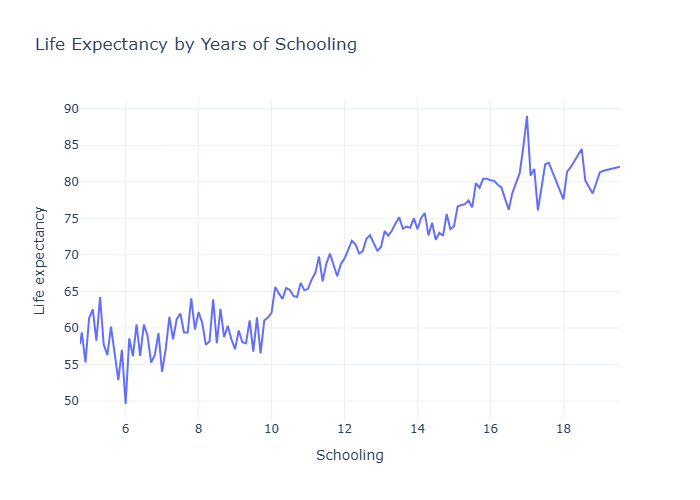

In [35]:
# Life Expectancy vs Schooling
px.line(df.groupby("Schooling")["Life expectancy"].mean().reset_index(), x="Schooling", y="Life expectancy",
        title="Life Expectancy by Years of Schooling",template="plotly_white").show("png")

In [36]:
#Statistical Analysis

In [37]:
df["income_group"]=pd.qcut(
    df["Income composition of resources"],
    q=3,
    labels=["Low","Medium","High"]
)

In [38]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,income_group
0,Afghanistan,2015,Developing,65.0,263.0,53.5,0.01,71.279624,65.0,932.5,19.1,71,57.0,8.16,65.0,0.1,584.259210,18859584.5,15.35,15.2,0.479,10.1,Low
1,Afghanistan,2014,Developing,59.9,271.0,53.5,0.01,73.523582,62.0,492.0,18.6,71,58.0,8.18,62.0,0.1,612.696514,327582.0,15.35,15.2,0.476,10.0,Low
2,Afghanistan,2013,Developing,59.9,268.0,53.5,0.01,73.219243,64.0,430.0,18.1,71,62.0,8.13,64.0,0.1,631.744976,18859584.5,15.35,15.2,0.470,9.9,Low
3,Afghanistan,2012,Developing,59.5,272.0,53.5,0.01,78.184215,67.0,932.5,17.6,71,67.0,8.52,67.0,0.1,669.959000,3696958.0,15.35,15.2,0.463,9.8,Low
4,Afghanistan,2011,Developing,59.2,275.0,53.5,0.01,7.097109,68.0,932.5,17.2,71,68.0,7.87,68.0,0.1,63.537231,2978599.0,15.35,15.2,0.454,9.5,Low


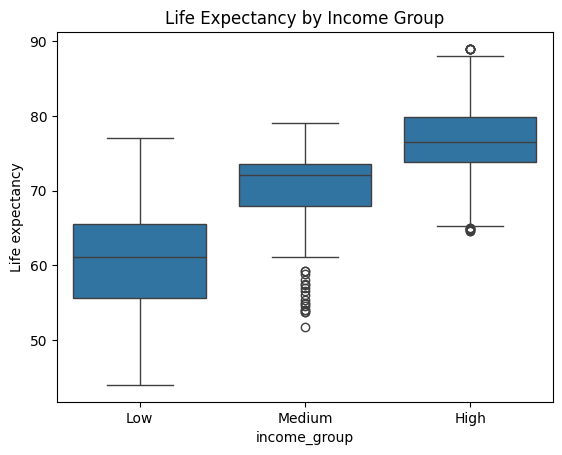

In [39]:
sns.boxplot(x="income_group",y="Life expectancy",data=df)
plt.title("Life Expectancy by Income Group")
plt.show()

## 6. Feature Selection

In [40]:
X = df[["Adult Mortality","Alcohol","Hepatitis B","Measles","BMI","Polio","Total expenditure","Diphtheria","HIV/AIDS","GDP","Income composition of resources","Schooling"]]
y = df["Life expectancy"]

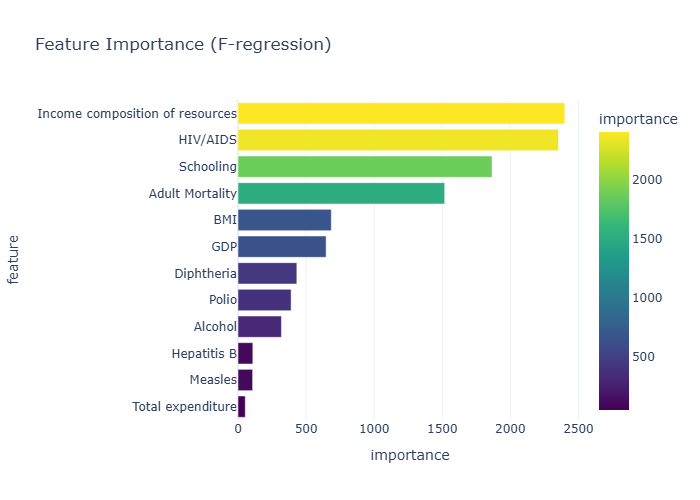

In [41]:
# Feature importance (F-regression)
selector = SelectKBest(score_func=f_regression, k='all').fit(X, y)
importance_df = pd.DataFrame({"feature": X.columns, "importance": selector.scores_}).sort_values("importance", ascending=True)
px.bar(importance_df,
       x="importance",
       y="feature",
       orientation="h",
       color='importance',
       color_continuous_scale='Viridis',
       title="Feature Importance (F-regression)",
       template="plotly_white"
      ).show("png")

## 7. Data Preprocessing

In [42]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
scaler=StandardScaler()
x_train=scaler.fit_transform(X_train)
x_test=scaler.transform(X_test)

## 8. Model Training & Evaluation

In [44]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=300),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.2,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8
    )
}

In [45]:
results = []
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    results.append({'Model': name, 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)), 'R2 Score': r2_score(y_test, y_pred)})

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
results_df

,Model,RMSE,R2 Score
0,Extra Trees,1.799150,0.954424
1,Random Forest,2.075051,0.939374
2,XGBoost,2.167289,0.933864
3,Gradient Boosting,2.367585,0.921075


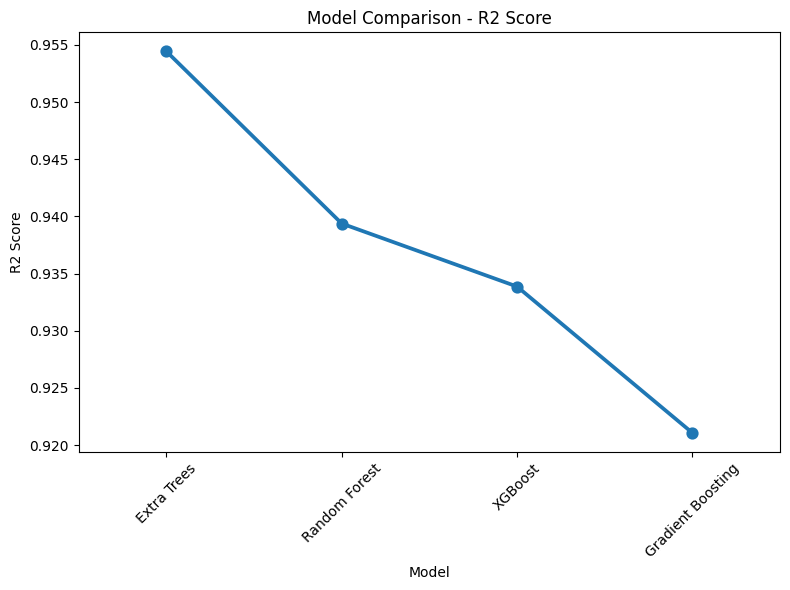

In [46]:
# Plot model comparison
plt.figure(figsize=(8,6))
sns.pointplot(data=results_df, x='Model', y='R2 Score')
plt.title('Model Comparison - R2 Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

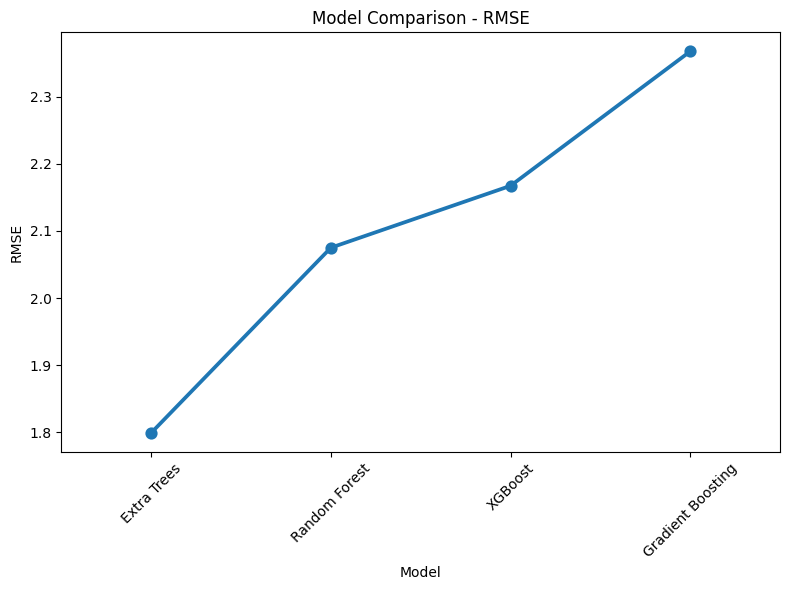

In [47]:
plt.figure(figsize=(8,6))
sns.pointplot(data=results_df, x='Model', y='RMSE')
plt.title('Model Comparison - RMSE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Feature Importance


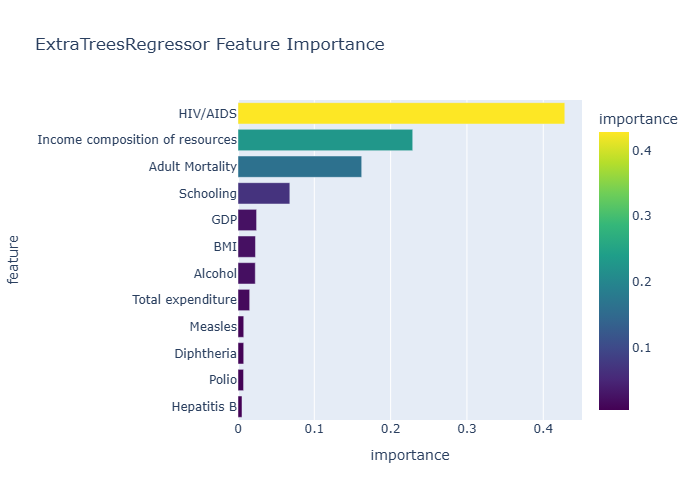

In [48]:
# Feature Importance from best model (using ExtraTreesRegressor here)
best_model = ExtraTreesRegressor()
best_model.fit(x_train, y_train)
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

fig = px.bar(importance_df, x='importance', y='feature', orientation='h',
             color='importance', color_continuous_scale='Viridis',
             title='ExtraTreesRegressor Feature Importance')
fig.update_layout(height=500)
fig.show("png")

## 10. Cross Validation

In [49]:
# Cross Validation for Best Model
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ExtraTreesRegressor(n_estimators=300, random_state=42))
])

cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')

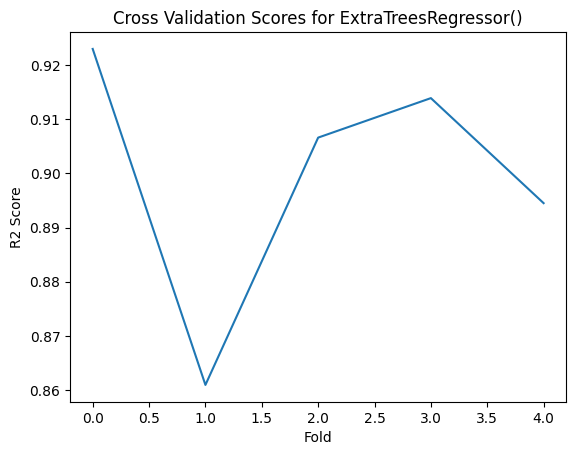

Cross-validation Mean R2: 0.8998
Cross-validation Std R2: 0.0216


In [50]:
plt.plot(cv_scores)
plt.xlabel('Fold')
plt.ylabel('R2 Score')
plt.title(f'Cross Validation Scores for {best_model}')
plt.show()

print(f"Cross-validation Mean R2: {cv_scores.mean():.4f}")
print(f"Cross-validation Std R2: {cv_scores.std():.4f}")